# Customer Churn Prediction Exploration

Date: 2026-02-26 
Author: Sajad Ahmadnezhad  
Description: Exploring how machine learning can be used to predict customer churn using the Telco Customer Churn dataset. In this exploration, Logistic Regression is applied and compared with a Decision Tree model to better understand how different algorithms perform on the same dataset.

## 0. Problem Statement

Can we predict whether a customer will churn based on customer characteristics, service usage, and billing information?

Which features appear to have the strongest influence on churn?

Additionally, how does Logistic Regression perform compared to a Decision Tree model when predicting customer churn?

## 1. Import Libraries

In this section, the required libraries are imported for data analysis, visualization, preprocessing, model training, evaluation, and model saving.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Save and load models
import joblib

## 2. Notebook Settings

These settings improve the readability of the notebook output.

They help by:

- showing all columns in dataframes
- showing more rows when needed
- displaying full text inside cells
- making plots larger and easier to read

Warnings are intentionally kept visible in this notebook, because they can help detect important issues during learning and model development.

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 3. Load Dataset and Initial Data Inspection

In this section, the dataset is loaded and inspected to understand its structure.

The following checks are performed:

- preview of the first rows
- dataset shape
- column names
- general dataset information
- missing values
- duplicate rows
- data types

This step is important because it gives a first overview of the dataset before cleaning and preprocessing.

In [3]:
df = pd.read_csv("telco-customer-churn.csv", sep=";")

print("First 5 rows:")
display(df.head())

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().sum() / len(df)) * 100)

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Shape:
(7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   On

## 4. Data Overview and Quality Report

After the initial inspection, a deeper overview of the dataset is created.

This includes:

- unique values in categorical columns
- statistical summary of numerical columns
- a structured data quality report

This helps detect inconsistent values, missing data, and possible cleaning issues.

In [4]:
categorical_cols = df.select_dtypes(include="object").columns
numeric_cols = df.select_dtypes(include=np.number).columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

Column: gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Column: Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Column: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Column: PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Column: MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Column: InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Column: OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Column: OnlineBack

C:\Users\sajad\AppData\Local\Temp\ipykernel_30372\2735757070.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [5]:
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
def data_quality_report(dataframe):
    report = pd.DataFrame({
        "column": dataframe.columns,
        "dtype": dataframe.dtypes.values,
        "missing_count": dataframe.isnull().sum().values,
        "missing_percent": ((dataframe.isnull().sum() / len(dataframe)) * 100).values,
        "unique_values": dataframe.nunique().values
    })
    return report.sort_values(by="missing_percent", ascending=False)

quality_report = data_quality_report(df)
display(quality_report)

,column,dtype,missing_count,missing_percent,unique_values
0,customerID,str,0,0.0,7043
1,gender,str,0,0.0,2
2,SeniorCitizen,int64,0,0.0,2
3,Partner,str,0,0.0,2
4,Dependents,str,0,0.0,2
5,tenure,int64,0,0.0,73
6,PhoneService,str,0,0.0,2
7,MultipleLines,str,0,0.0,3
8,InternetService,str,0,0.0,3
9,OnlineSecurity,str,0,0.0,3


## 5. Data Cleaning and Preparation

In this section, the dataset is cleaned and prepared for machine learning.

The following steps are performed:

- remove extra spaces from text values
- standardize inconsistent categorical values
- convert selected binary columns into numeric format
- convert the target column into binary format
- review the cleaned dataset structure

This step is essential because machine learning models require clean and consistent data.

In [45]:
# Reload dataset from the original file
df = pd.read_csv("telco-customer-churn.csv", sep=";")

# Remove extra spaces from text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

# Standardize inconsistent categorical values
df = df.replace("No phone service", "No")
df = df.replace("No internet service", "No")

# Simplify InternetService values
if "InternetService" in df.columns:
    df["InternetService"] = df["InternetService"].replace({
        "DSL": "Yes",
        "Fiber optic": "Yes",
        "No": "No"
    })

# Convert binary categorical columns to numeric
binary_mappings = {
    "gender": {"Male": 1, "Female": 0},
    "Partner": {"Yes": 1, "No": 0},
    "Dependents": {"Yes": 1, "No": 0},
    "PhoneService": {"Yes": 1, "No": 0},
    "MultipleLines": {"Yes": 1, "No": 0},
    "InternetService": {"Yes": 1, "No": 0},
    "OnlineSecurity": {"Yes": 1, "No": 0},
    "OnlineBackup": {"Yes": 1, "No": 0},
    "DeviceProtection": {"Yes": 1, "No": 0},
    "TechSupport": {"Yes": 1, "No": 0},
    "StreamingTV": {"Yes": 1, "No": 0},
    "StreamingMovies": {"Yes": 1, "No": 0},
    "PaperlessBilling": {"Yes": 1, "No": 0},
    "Churn": {"Yes": 1, "No": 0}
}

for col, mapping in binary_mappings.items():
    if col in df.columns:
        df[col] = df[col].replace(mapping)
        
# Convert TotalCharges to numeric
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

if "TotalCharges" in df.columns:
    df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("First rows after cleaning:")
display(df.head())

print("\nData types after cleaning:")
print(df.dtypes)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

First rows after cleaning:


C:\Users\sajad\AppData\Local\Temp\ipykernel_30372\2326575075.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,0,1,0,1,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,0,1,1,0,1,0,0,0,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,1,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,0,1,1,0,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,0,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1



Data types after cleaning:
customerID              str
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract                str
PaperlessBilling     object
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract

## 6. Feature Encoding

In this step, the remaining categorical columns with multiple categories are converted into numerical format.

The following columns are encoded using one-hot encoding:

- Contract
- PaymentMethod

This allows machine learning models to use these features without incorrectly assuming any numeric ordering between categories.

In [61]:
# Encode only multi-category columns on a new dataframe
cols_to_encode = []

if "Contract" in df.columns:
    cols_to_encode.append("Contract")

if "PaymentMethod" in df.columns:
    cols_to_encode.append("PaymentMethod")

df_encoded = pd.get_dummies(
    df.copy(),
    columns=cols_to_encode,
    drop_first=True,
    dtype=int
)
df = df_encoded

print("First rows after feature encoding:")
display(df_encoded.head())

print("\nColumns after encoding:")
print(df_encoded.columns.tolist())

print("\nData types after encoding:")
print(df.dtypes)

First rows after feature encoding:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,0,1,0,1,0,0,0,0,1,29.85,29.85,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,1,1,0,1,0,0,0,0,56.95,1889.50,0,1,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,0,1,1,1,0,0,0,0,1,53.85,108.15,1,0,0,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,0,1,1,0,1,1,0,0,0,42.30,1840.75,0,1,0,0,0,0
4,9237-HQITU,0,0,0,0,2,1,0,1,0,0,0,0,0,0,1,70.70,151.65,1,0,0,0,1,0



Columns after encoding:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Data types after encoding:
customerID                                   str
gender                                    object
SeniorCitizen                              int64
Partner                                   object
Dependents                                object
tenure                                     int64
PhoneService                              object
MultipleLines                             object
InternetService                           object
OnlineSecurity                            object
OnlineBackup   

## 7. Feature and Target Split

In this step, the dataset is divided into:

- `X`: the input features
- `y`: the target variable

The `customerID` column is removed because it is only an identifier and does not provide useful information for prediction.

The `Churn` column is used as the target variable.

In [62]:
df["Churn"] = df["Churn"].astype(int)
# Define features and target
X = df.drop(["customerID", "Churn"], axis=1)
y = df["Churn"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFirst rows of X:")
display(X.head())

print("\nFirst rows of y:")
display(y.head())

Feature matrix shape: (7043, 22)
Target vector shape: (7043,)

First rows of X:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,1,29.85,29.85,0,0,0,1,0
1,1,0,0,0,34,1,0,1,1,0,1,0,0,0,0,56.95,1889.50,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,1,0,0,0,0,1,53.85,108.15,0,0,0,0,1
3,1,0,0,0,45,0,0,1,1,0,1,1,0,0,0,42.30,1840.75,1,0,0,0,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,1,70.70,151.65,0,0,0,1,0



First rows of y:


0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

## 8. Train-Test Split

To evaluate the model properly, the dataset is divided into training and testing sets.

The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

In this project, an 80/20 split is used.

In [63]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTarget distribution in training set:")
print(y_train.value_counts())

print("\nTarget distribution in test set:")
print(y_test.value_counts())

Training set shape: (5634, 22)
Testing set shape: (1409, 22)

Target distribution in training set:
Churn
0    4139
1    1495
Name: count, dtype: int64

Target distribution in test set:
Churn
0    1035
1     374
Name: count, dtype: int64


## 9. Feature Scaling

In this step, feature scaling is applied to the dataset.

Some numerical features in the dataset have different ranges. This can affect the performance of certain machine learning algorithms, especially Logistic Regression.

To address this, StandardScaler from the scikit-learn library is used to standardize the features. This transformation scales the data so that it has a mean close to 0 and a standard deviation close to 1.

The scaler is fitted only on the training data and then applied to both the training and test datasets to prevent data leakage.

In [71]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train)

display(X_train_scaled.head())

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
0,0.994336,-0.441773,-0.969234,-0.651557,0.102371,-3.013090,-0.858338,0.524081,-0.636111,-0.735546,1.375572,-0.643274,1.252163,1.247967,-1.202653,-0.521976,-0.263289,-0.512782,-0.563822,-0.523806,1.406903,-0.543846
1,0.994336,-0.441773,1.031742,1.534786,-0.711743,0.331885,-0.858338,0.524081,1.572053,-0.735546,-0.726971,-0.643274,-0.798618,-0.801303,-1.202653,0.337478,-0.504814,-0.512782,-0.563822,-0.523806,-0.710781,1.838757
2,0.994336,-0.441773,1.031742,1.534786,-0.793155,-3.013090,-0.858338,0.524081,1.572053,1.359534,-0.726971,1.554547,-0.798618,-0.801303,-1.202653,-0.809013,-0.751213,-0.512782,1.773611,-0.523806,-0.710781,1.838757
3,-1.005696,-0.441773,1.031742,-0.651557,-0.263980,0.331885,-0.858338,0.524081,-0.636111,1.359534,1.375572,-0.643274,1.252163,1.247967,0.831495,0.284384,-0.173699,-0.512782,1.773611,1.909105,-0.710781,-0.543846
4,0.994336,-0.441773,1.031742,1.534786,-1.281624,0.331885,-0.858338,0.524081,-0.636111,-0.735546,-0.726971,-0.643274,-0.798618,-0.801303,-1.202653,-0.676279,-0.990851,-0.512782,-0.563822,-0.523806,1.406903,-0.543846


## 10. Model Training

In this step, two machine learning models are trained:

- Logistic Regression
- Decision Tree

These models are trained on the training dataset and will later be evaluated and compared.

In [80]:
# Train Logistic Regression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

# Train Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Training accuracy
print("Logistic Regression training accuracy:", log_model.score(X_train, y_train))
print("Decision Tree training accuracy:", tree_model.score(X_train, y_train))

Logistic Regression training accuracy: 0.8059992900248492
Decision Tree training accuracy: 0.9980475683351083


## 11. Model Evaluation

After training the models, the next step is to evaluate their performance on the test dataset.

This evaluation helps determine how well the models generalize to unseen data.

The following evaluation metrics are used:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics provide a deeper understanding of the models' performance beyond simple accuracy.

In [82]:
# Predictions
y_pred_log = log_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)

print("Logistic Regression Evaluation")
print(classification_report(y_test, y_pred_log))

print("Decision Tree Evaluation")
print(classification_report(y_test, y_pred_tree))

Logistic Regression Evaluation
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

Decision Tree Evaluation
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1035
           1       0.50      0.52      0.51       374

    accuracy                           0.74      1409
   macro avg       0.66      0.67      0.66      1409
weighted avg       0.74      0.74      0.74      1409



<Figure size 600x500 with 0 Axes>

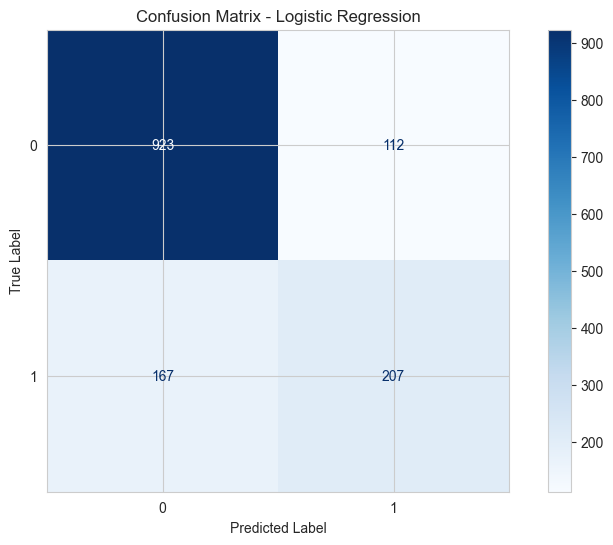

<Figure size 600x500 with 0 Axes>

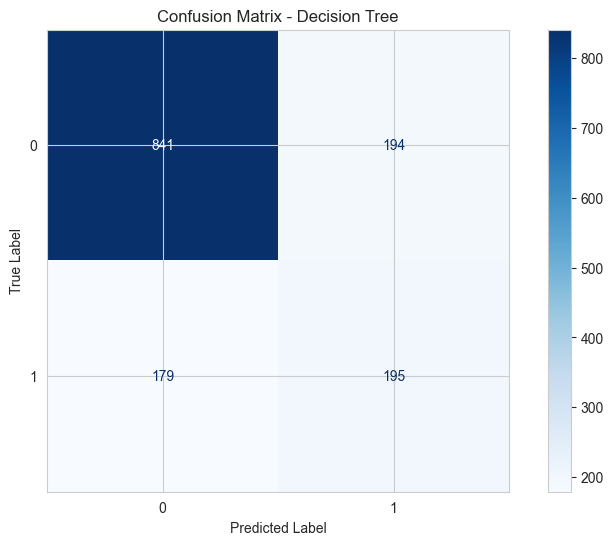

In [83]:
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


plt.figure(figsize=(6,5))
ConfusionMatrixDisplay.from_estimator(
    tree_model,
    X_test,
    y_test,
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show() 

## 12. Cross Validation

In this step, cross validation is used to evaluate the stability and reliability of the machine learning models.

Instead of evaluating the model using a single train-test split, the dataset is divided into multiple folds. The model is trained and evaluated multiple times using different subsets of the data.

In this project, 5-fold cross validation is used to measure the average performance of the models.

This approach provides a more reliable estimate of how well the models generalize to unseen data.

In [84]:
# Logistic Regression Cross Validation
log_cv_scores = cross_val_score(log_model, X, y, cv=5)

print("Logistic Regression Cross Validation Scores:")
print(log_cv_scores)
print("Average Accuracy:", log_cv_scores.mean())

Logistic Regression Cross Validation Scores:
[0.80482612 0.80979418 0.79063165 0.80894886 0.80681818]
Average Accuracy: 0.8042037994386735


In [79]:
# Decision Tree Cross Validation
tree_cv_scores = cross_val_score(tree_model, X, y, cv=5)

print("Decision Tree Cross Validation Scores:")
print(tree_cv_scores)
print("Average Accuracy:", tree_cv_scores.mean())

Decision Tree Cross Validation Scores:
[0.73172463 0.7338538  0.71682044 0.72869318 0.73011364]
Average Accuracy: 0.728241136524937


## 13. Model Comparison

In this section, the performance of the two machine learning models is compared.

The models evaluated in this project are:

- Logistic Regression
- Decision Tree

Their performance is compared based on accuracy scores obtained during model evaluation and cross validation.

This comparison helps determine which model performs better for predicting customer churn.

In [85]:
# Test accuracy
log_test_acc = log_model.score(X_test, y_test)
tree_test_acc = tree_model.score(X_test, y_test)

print("Logistic Regression Test Accuracy:", log_test_acc)
print("Decision Tree Test Accuracy:", tree_test_acc)

Logistic Regression Test Accuracy: 0.8019872249822569
Decision Tree Test Accuracy: 0.7352732434350603


In [86]:
print("Logistic Regression CV Average:", log_cv_scores.mean())
print("Decision Tree CV Average:", tree_cv_scores.mean())

Logistic Regression CV Average: 0.8042037994386735
Decision Tree CV Average: 0.728241136524937


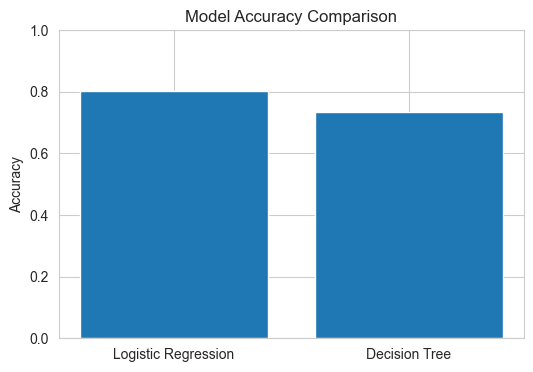

In [87]:
models = ["Logistic Regression", "Decision Tree"]
scores = [log_test_acc, tree_test_acc]

plt.figure(figsize=(6,4))
plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)

plt.show()

## 14. Feature Importance

In this section, the importance of different features is analyzed to understand which factors have the greatest impact on customer churn.

Feature importance helps identify the most influential variables in the prediction process.

For this analysis, the Decision Tree model is used because it provides a direct way to measure feature importance based on how much each feature contributes to the decision-making process.

Understanding these important features can help businesses focus on the key factors that influence customer retention.

In [88]:
feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

MonthlyCharges                           0.284906
tenure                                   0.197013
TotalCharges                             0.182119
PaymentMethod_Electronic check           0.042037
PaperlessBilling                         0.026250
gender                                   0.025876
Partner                                  0.022441
Dependents                               0.021182
DeviceProtection                         0.019599
Contract_One year                        0.019418
MultipleLines                            0.018556
Contract_Two year                        0.018441
TechSupport                              0.018285
OnlineBackup                             0.015820
OnlineSecurity                           0.015322
SeniorCitizen                            0.014500
PaymentMethod_Mailed check               0.012698
InternetService                          0.012695
StreamingMovies                          0.010152
StreamingTV                              0.009995


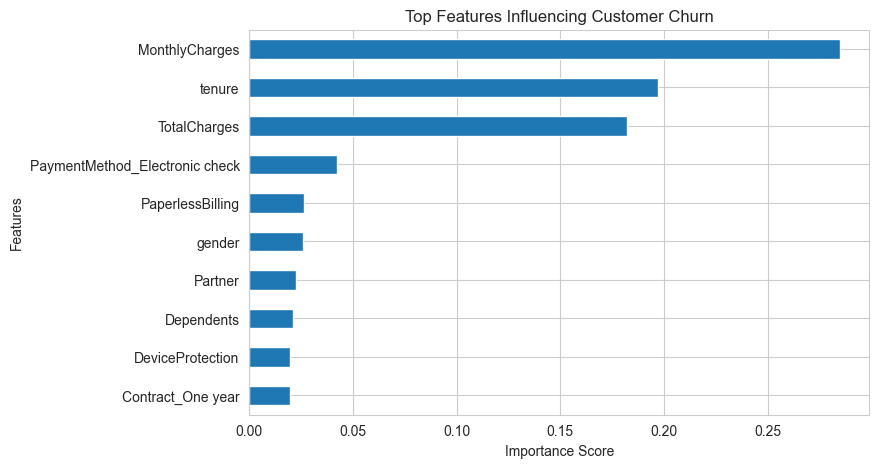

In [89]:
plt.figure(figsize=(8,5))

feature_importance.head(10).plot(kind="barh")

plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

## 15. Model Insights and Feature Analysis

In this section, the impact of different features on customer churn is analyzed.

Visualizations are used to better understand how specific variables influence the model’s predictions and the likelihood of customer churn.

By examining these patterns, we can identify key factors that contribute to customer churn and gain deeper insights into customer behavior.

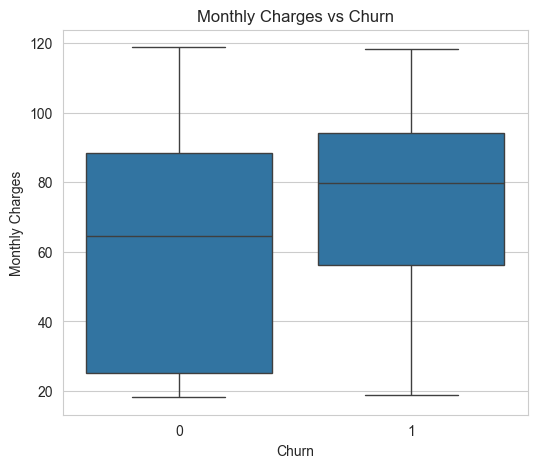

In [90]:
plt.figure(figsize=(6,5))

sns.boxplot(x=df["Churn"], y=df["MonthlyCharges"])

plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges vs Churn")

plt.show()

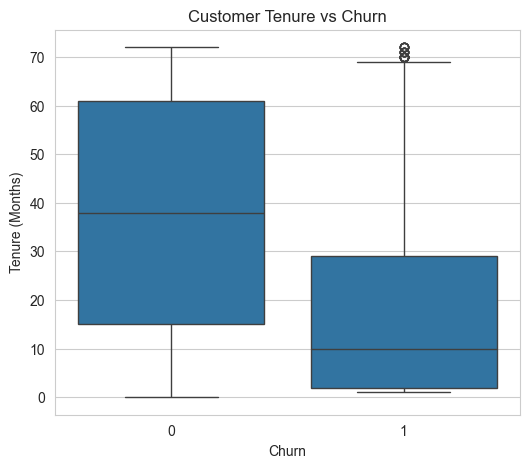

In [92]:
plt.figure(figsize=(6,5))

sns.boxplot(x=df["Churn"], y=df["tenure"])

plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.title("Customer Tenure vs Churn")

plt.show()

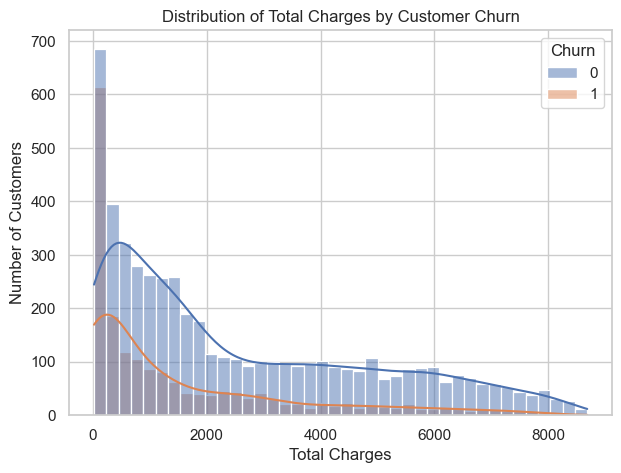

In [107]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    bins=40,
    kde=True
)

plt.title("Distribution of Total Charges by Customer Churn")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

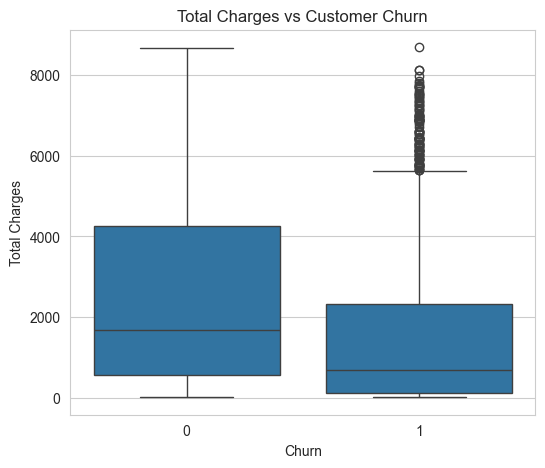

In [101]:
plt.figure(figsize=(6,5))

sns.boxplot(x=df["Churn"], y=df["TotalCharges"])

plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.title("Total Charges vs Customer Churn")

plt.show()

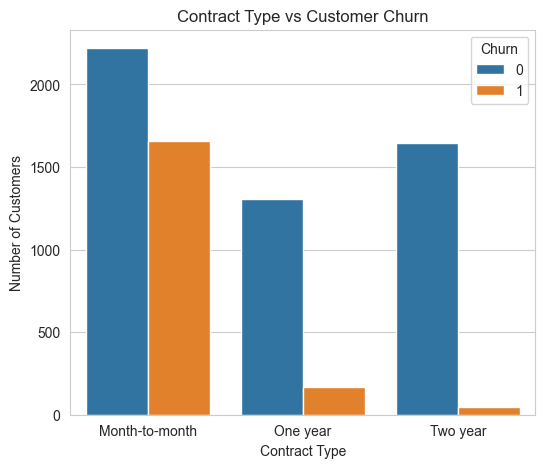

In [99]:
df_contract = df.copy()

df_contract["ContractType"] = "Month-to-month"

df_contract.loc[df_contract["Contract_One year"] == 1, "ContractType"] = "One year"
df_contract.loc[df_contract["Contract_Two year"] == 1, "ContractType"] = "Two year"
plt.figure(figsize=(6,5))

sns.countplot(x="ContractType", hue="Churn", data=df_contract)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

## 16. Saving the Models

After training and evaluating the machine learning models, the trained models are saved for future use.

Saving the models allows them to be reused later without retraining. This is useful for applications such as dashboards, APIs, or deployment systems where predictions need to be generated for new customer data.

In this project, both the Logistic Regression model and the Decision Tree model are saved so they can be used later for customer churn prediction.

In [111]:
joblib.dump(log_model, "logistic_regression_churn_model.pkl")
joblib.dump(tree_model, "decision_tree_churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Models and scaler saved successfully")

Models and scaler saved successfully


## 17. Conclusion

In this project, machine learning techniques were applied to analyze and predict customer churn using the Telco Customer Churn dataset. The goal of this analysis was to identify patterns in customer behavior and determine which factors influence whether a customer is likely to leave the company.

Two machine learning models were trained and evaluated: **Logistic Regression** and **Decision Tree**. After evaluating the models using accuracy scores, classification reports, confusion matrices, and cross-validation, the Logistic Regression model showed better overall performance and more stable results on unseen data compared to the Decision Tree model.

Further analysis of the dataset revealed several important insights related to customer churn. Customers with **month-to-month contracts** were significantly more likely to churn compared to customers with longer-term contracts. Additionally, customers with **lower total charges** were more likely to leave the company, which suggests that many churned customers had been with the company for a relatively short period of time.

The feature analysis also showed that  **monthly charges**, **tenure**, and **total charges** are among the most influential factors affecting churn behavior. These insights can help businesses understand customer behavior and develop strategies to improve customer retention.

Overall, this project demonstrates how machine learning can be used to analyze customer data, identify churn patterns, and support data-driven decision making in business environments.